In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [11]:
csv_path = "art_restoration_dataset_new.csv"
df = pd.read_csv(csv_path)
print(df.head())

                                          image_name    blur_score  \
0           a.y.-jackson_algoma-in-november-1935.jpg   7433.585588   
1    a.y.-jackson_first-snow-algoma-country-1920.jpg  12492.219826   
2  a.y.-jackson_frozen-lake-early-spring-algonqui...   5927.211369   
3         a.y.-jackson_grey-day-laurentians-1928.jpg  12555.249751   
4     a.y.-jackson_hills-at-great-bear-lake-1953.jpg   6947.372041   

   brightness   contrast  edge_count  noise_level   entropy  saturation  \
0  137.110504  24.350313       14505   116.208617  6.502122   47.366776   
1  169.798691  28.904065       21140   112.298345  6.801705   47.773865   
2  142.860321  21.680555       11541   117.322070  6.312884   41.071671   
3  157.030731  31.126185       18790   112.916258  6.885242   60.443909   
4  111.186356  20.924226       14985   116.170221  6.369854   60.741074   

      sharpness  dark_ratio  white_ratio  contour_count  width  height  \
0   7433.585588    0.000000     0.000000            91

In [12]:
print(df.shape)
print(df.columns)

(5348, 18)
Index(['image_name', 'blur_score', 'brightness', 'contrast', 'edge_count',
       'noise_level', 'entropy', 'saturation', 'sharpness', 'dark_ratio',
       'white_ratio', 'contour_count', 'width', 'height', 'aspect_ratio',
       'mean_red', 'mean_green', 'mean_blue'],
      dtype='object')


In [ ]:
df['degradation_score'] = ((df['noise_level'] * 0.3) +(df['dark_ratio'] * 100) +(df['white_ratio'] * 100) +(df['edge_count'] * 0.002) +(df['contrast'] * 0.2))
df['visual_quality_score'] = (
    (df['sharpness'] * 0.4) +
    (df['brightness'] * 0.2) +
    (df['saturation'] * 0.2) +
    (df['entropy'] * 5))

df['texture_complexity'] = (
    (df['entropy'] * 10) +
    (df['contour_count'] * 0.5))

df['color_richness'] = (
    df['mean_red'] +
    df['mean_green'] +
    df['mean_blue']) / 3

df['crack_intensity'] = (
    (df['white_ratio'] * 100) +
    (df['edge_count'] * 0.001))

df['blur_intensity'] = (
    1000 / (df['blur_score'] + 1))

def restoration_level(row):
    score = (
        row['degradation_score'] +
        row['crack_intensity'] +
        row['blur_intensity'])

    if score < 60:
        return 0
    elif score < 120:
        return 1
    elif score < 180:
        return 2
    else:
        return 3
df['target'] = df.apply(
    restoration_level,
    axis=1)

def level_name(x):
    if x == 0:
        return "Easy"
    elif x == 1:
        return "Moderate"
    elif x == 2:
        return "Difficult"
    else:
        return "Impossible"

df['restoration_name'] = df['target'].apply(level_name)

In [14]:
print(df['restoration_name'].value_counts())

restoration_name
Moderate      4251
Easy          1009
Difficult       65
Impossible      23
Name: count, dtype: int64


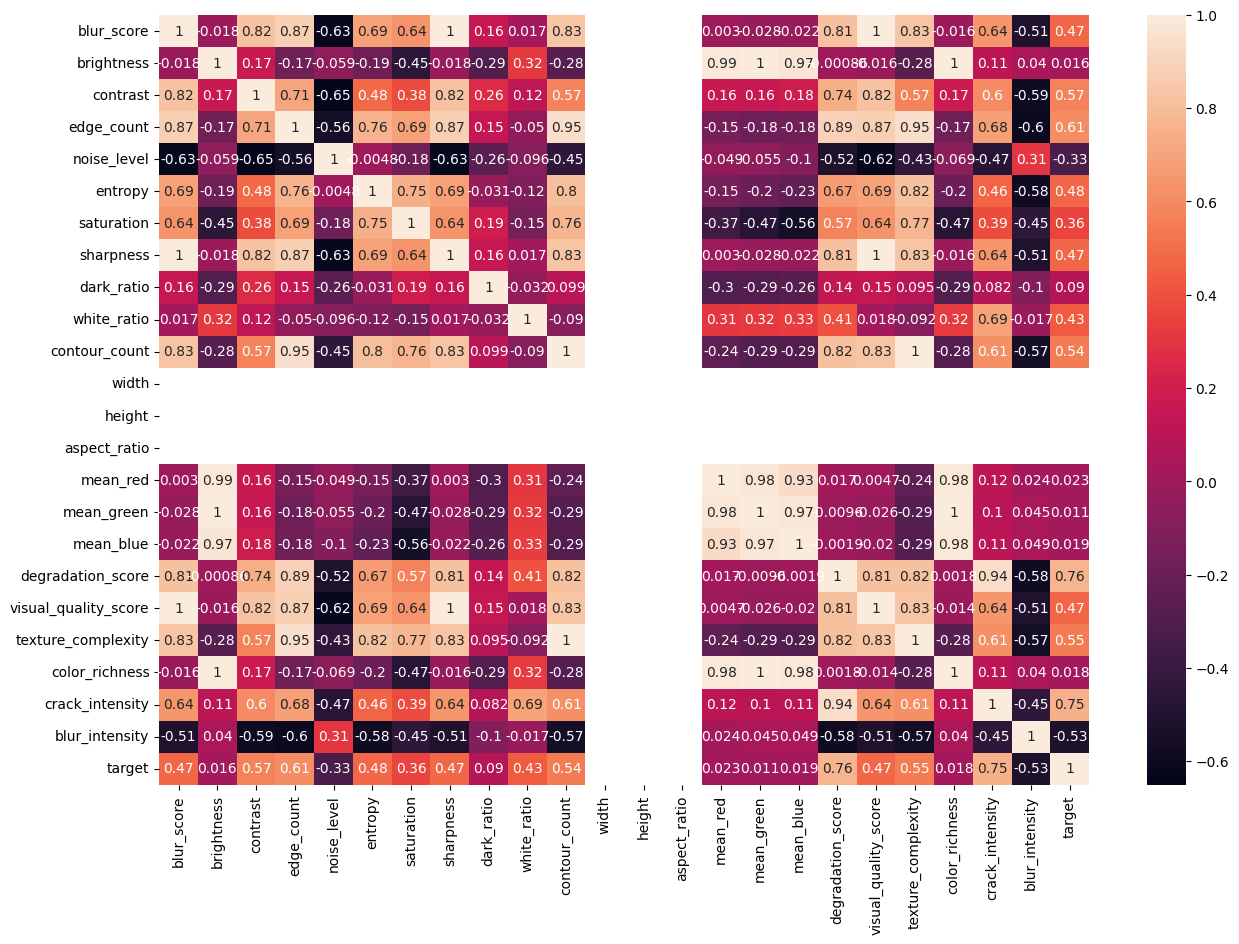

In [16]:
plt.figure(figsize=(15,10))
sn.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()


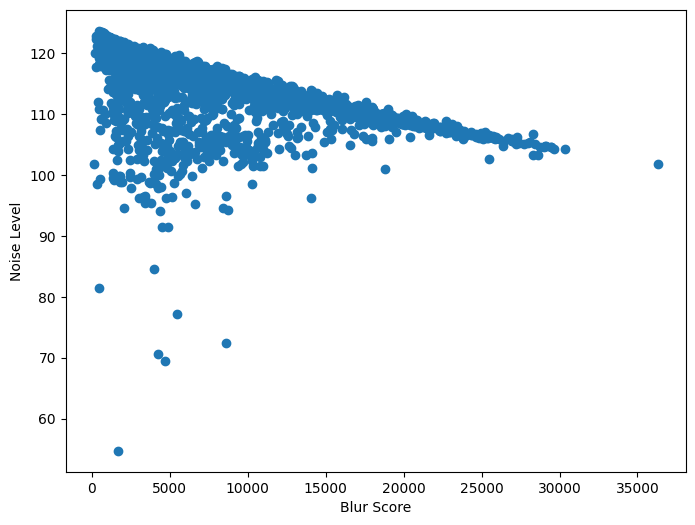

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['blur_score'],
    df['noise_level'])
plt.xlabel('Blur Score')
plt.ylabel('Noise Level')
plt.show()

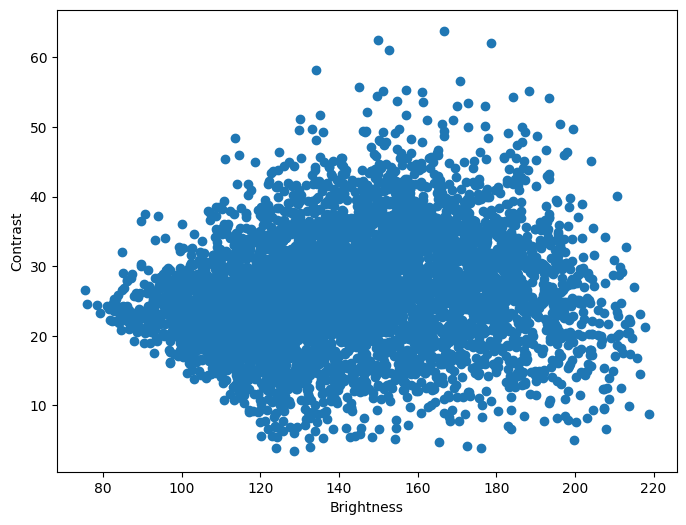

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(df['brightness'],df['contrast'])
plt.xlabel('Brightness')
plt.ylabel('Contrast')
plt.show()

In [19]:
X = df[[
    'blur_score',
    'brightness',
    'contrast',
    'edge_count',
    'noise_level',
    'entropy',
    'saturation',
    'sharpness',
    'dark_ratio',
    'white_ratio',
    'contour_count',
    'aspect_ratio',
    'mean_red',
    'mean_green',
    'mean_blue',
    'degradation_score',
    'visual_quality_score',
    'texture_complexity',
    'color_richness',
    'crack_intensity',
    'blur_intensity']]
y = df['target']

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=1)

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9906542056074766

In [22]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9981308411214953

In [23]:
model = SVC()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.983177570093458

In [24]:
model = GaussianNB()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9168224299065421

In [25]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9757009345794393

In [28]:
model = RandomForestClassifier(n_estimators=200,random_state=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9962616822429906

In [29]:
param_grid = {'n_estimators': [50,100,200],'max_depth': [3,5,10,None]}
grid = GridSearchCV(RandomForestClassifier(),param_grid,cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'n_estimators': 200}
0.9943897906760671


In [30]:
final_model = RandomForestClassifier(n_estimators=grid.best_params_['n_estimators'],max_depth=grid.best_params_['max_depth'],random_state=1)

In [31]:
final_model.fit(X_train, y_train)
print("Final Accuracy:",final_model.score(X_test, y_test))
y_pred = final_model.predict(X_test)

Final Accuracy: 0.9962616822429906


In [32]:
print(y_pred[:10])
cm = confusion_matrix(y_test,y_pred)
print(cm)

[0 1 1 1 1 0 1 1 1 1]
[[183   2   0   0]
 [  1 866   0   0]
 [  0   0  10   1]
 [  0   0   0   7]]


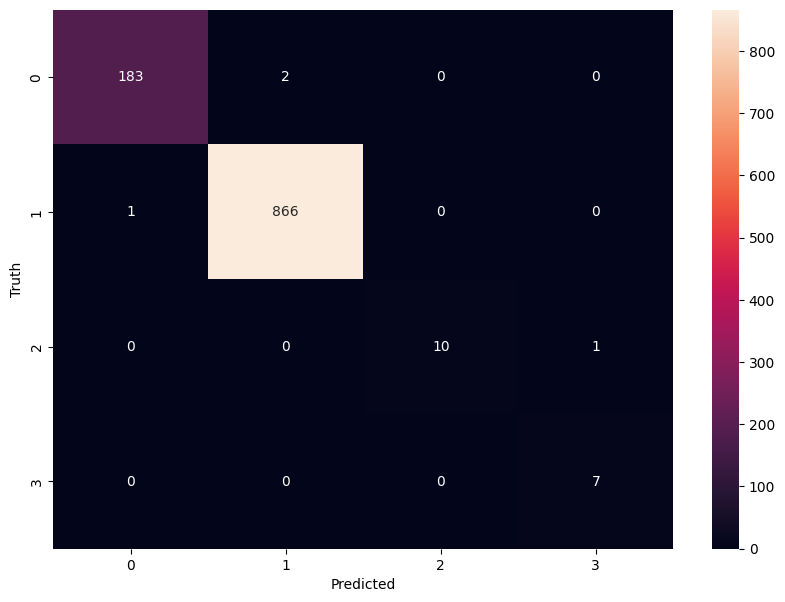

In [33]:
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       185
           1       1.00      1.00      1.00       867
           2       1.00      0.91      0.95        11
           3       0.88      1.00      0.93         7

    accuracy                           1.00      1070
   macro avg       0.97      0.97      0.97      1070
weighted avg       1.00      1.00      1.00      1070



In [35]:
import joblib
joblib.dump(final_model,'art_restoration_model.pkl')

['art_restoration_model.pkl']

In [ ]:
sample = [[
    200,
    120,
    50,
    4000,
    20,
    5,
    100,
    200,
    0.2,
    0.05,
    100,
    1.0,
    120,
    110,
    100,
    50,
    100,
    80,
    110,
    20,
    5
]]

sample = scaler.transform(sample)

prediction = model.predict(sample)



[0]


c:\Users\sanjay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
print(prediction)

[0]
